Pipeline template

Notebook to illustrate the overall pipeline flow including:

- reading in data
- adding non signal noise
- modifying record to be input ready
- inputting to DMD
- converting recovered outputs to comparable outputs
- examining recovery metrics

## Preamble

In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pydmd import DMD, BOPDMD
from pydmd.preprocessing import hankel_preprocessing

# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Application


## Reading in data

In [22]:
# Defining test parameters

# defining modes used
mode_numbers = ['62', '6', '13', '48', '1', '45', '29']
mode_numbers = [str(mode_number) for mode_number in mode_numbers]

# defining spherical harmonic degree cutoff
nmax = 5

hankel=False
embedding_d=10

weight_flag = True

dmd_type_used = 'exact'

bopdmd=False
bopdmd_params = {
    "num_trials":50,
    "trial_size":0.9,
    "remove_bad_bags":True,
}

fbdmd = False

svd_rank = 0.99

# LOADING IN DATA

# CHAOS gauss coeffs
gnm_chaos = CHAOS_Full_SV_Record_Obtain(nmax=nmax)



Full CHAOS-8.6 timespan is: [1997.1 2026.6]


## Comparing recovery success


In [23]:
# BELOW = takes synthetic record, tests results for: ideal, resolved, background, uncertainty ensemble (resolved)
n_ensembles = 100
results_dict = {}
syn_suite_info = {}

A_r = Truncate_Gauss_Coeffs(A_15_r, tmax=nmax)
perturbation_path = (
    Path(CHAOS_COV_DIR)
    / (
        "CHAOS_0806_nmax15_SV_nTyr_perturbations_N1000_Nt53.h5"
    )
)

# examining each mode number individually as a signal
for mode_key in tqdm(mode_numbers, desc="running each mode individually"):

    mode_num = [mode_key]

    # Getting synthetic ideal and resolved record
    gnm_syn_ideal, gnm_syn, syn_mode_info = Synthetic_Full_SV_Record_Obtain(mode_num, times_used_relative, nmax=nmax)
    mode_info = syn_mode_info[mode_key]
    syn_suite_info[mode_key] = mode_info

    # Generating resolved + background modelled signal
    gnm_syn_non_wave = Non_Wave_Spectral_Infill(gnm_chaos, gnm_syn, dt_sample=dt_sample)
    gnm_syn_infilled = gnm_syn + gnm_syn_non_wave

    # intialising results dictionary
    results_dict[mode_key] = {}

    record_dict = {
        "ideal":gnm_syn_ideal,
        "resolved":gnm_syn,
        # "background":gnm_syn_infilled,
    }

    for record_key in record_dict:

        record_used = record_dict[record_key]

        # projecting to physical space
        record_physical = A_r @ record_used.T

        # running DMD
        recovered_modes = Run_DMD(record_physical, times_used_relative, dmd_type_used, svd_rank, hankel, embedding_d, fbdmd, weighted=weight_flag)

        # matching input and output modes
        match_result = Match_Input_Output_Mode(mode_info, recovered_modes, nmax)

        results_dict[mode_key][record_key] = match_result

    # running perturbation ensembles
    ensemble_result = {
        "period_error":[],
        "similarity":[],
        "no_match_count":0,
    }

    with h5py.File(perturbation_path, "r") as f:

        for i in range(n_ensembles):

            gnm_perturbation_i = f["perturbations"][i, :, :].T

            # truncating to nmax
            gnm_perturbation_i = Truncate_Gauss_Coeffs(gnm_perturbation_i, tmax=nmax)
            gnm_perturbed_i = gnm_syn + gnm_perturbation_i

            # projecting to physical space
            record_physical = A_r @ gnm_perturbed_i.T

            # running DMD
            recovered_modes = Run_DMD(record_physical, times_used_relative, dmd_type_used, svd_rank, hankel, embedding_d, fbdmd, weighted=weight_flag)

            # matching input and output modes
            match_result = Match_Input_Output_Mode(mode_info, recovered_modes, nmax)

  
            if match_result:
                ensemble_result["period_error"].append(match_result["period_error"])
                ensemble_result["similarity"].append(match_result["similarity"])
            else:
                ensemble_result["no_match_count"] += 1

    results_dict[mode_key]["ensemble"] = ensemble_result


running each mode individually:   0%|          | 0/7 [00:00<?, ?it/s]

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 6.192123807613483e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 5.228398072518926e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 3.212238464939927e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.8032282174427764e+16. Consider preprocessing data, passing in augmented 

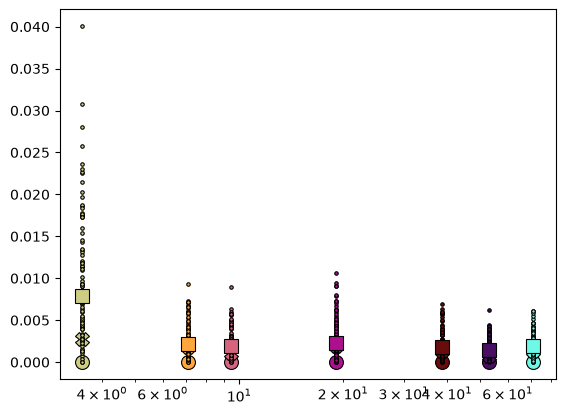

In [24]:
# looking at each record outcomes
plot_rules = {
    "ideal":{
        "shape":"o",
        "size":10,
    },
    "resolved":{
        "shape":"X",
        "size":10,
    },
    "background":{
        "shape":"^",
        "size":20,
    },
    "ensemble":{
        "shape":".",
        "size":5,
    }
}

mode_colours = {}
rng = np.random.default_rng(5)

for mode_key in mode_numbers:

    random_colour = rng.random(3)
    mode_colours[mode_key] = random_colour



for mode_key in mode_numbers:
    
    for result_type in results_dict[mode_key]:
        mode_result = results_dict[mode_key][result_type]

        mode_info = syn_suite_info[mode_key]
        period = mode_info["true_period"]

        if mode_result:

            if result_type == "ensemble":

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]
                num_unmatched = mode_result["no_match_count"]

                period_plot = period * np.ones_like(period_error)

            else:

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]

                period_plot = period

            plot_rule = plot_rules[result_type]

            plt.semilogx(period_plot, 
                        period_error, 
                        color=mode_colours[mode_key], 
                        marker=plot_rule["shape"], 
                        ms=plot_rule["size"], 
                        markeredgecolor="black",
                        markeredgewidth=0.8,
                        linestyle=' ')

            if result_type == "ensemble":
                plt.semilogx(period, 
                            np.median(period_error), 
                            color=mode_colours[mode_key], 
                            marker="s", 
                            ms=10, 
                            markeredgecolor="black",
                            markeredgewidth=0.8,
                            linestyle=' ')




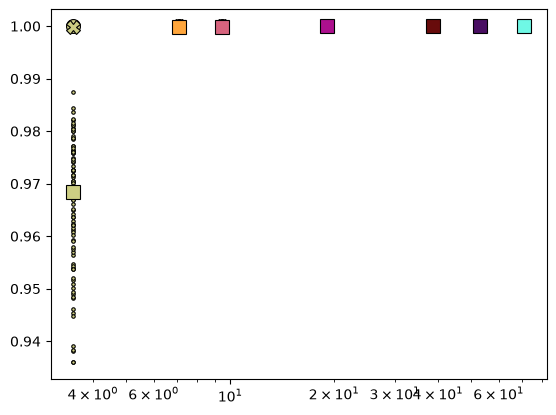

In [25]:

for mode_key in mode_numbers:

    for result_type in results_dict[mode_key]:

        mode_info = syn_suite_info[mode_key]
        period = mode_info["true_period"]
        mode_result = results_dict[mode_key][result_type]

        if mode_result:

            if result_type == "ensemble":

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]
                num_unmatched = mode_result["no_match_count"]

                period_plot = period * np.ones_like(period_error)

            else:

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]

                period_plot = period

            plot_rule = plot_rules[result_type]

            plt.semilogx(period_plot, 
                        similarity, 
                        color=mode_colours[mode_key], 
                        marker=plot_rule["shape"], 
                        ms=plot_rule["size"], 
                        markeredgecolor="black",
                        markeredgewidth=0.8,
                        linestyle=' ')

            if result_type == "ensemble":
                plt.semilogx(period, 
                            np.median(similarity), 
                            color=mode_colours[mode_key], 
                            marker="s", 
                            ms=10, 
                            markeredgecolor="black",
                            markeredgewidth=0.8,
                            linestyle=' ')